# 05 - Revenue Forecasting
Forecast MRR and new paid landlords 6 months forward. Compare a seasonal
naive baseline against exponential smoothing (Holt's linear trend method,
implemented directly with numpy/scipy since `statsmodels` isn't installable
in this offline sandbox -- the math is the same either way).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/warehouse.db")
rev = pd.read_sql("SELECT * FROM mart_revenue", conn, parse_dates=["month"])
rev = rev.sort_values("month").reset_index(drop=True)
rev = rev[rev["month"] <= "2025-10-01"]  # drop last 2 partial/edge months for cleaner backtest
rev[["month", "mrr", "paying_landlords"]].tail(10)

## Train/test split for backtesting
Hold out the last 6 months to evaluate forecast accuracy honestly.

In [2]:
series = rev.set_index("month")["mrr"]
train, test = series.iloc[:-6], series.iloc[-6:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} months)")

Train: 2022-01-01 to 2025-04-01 (40 months)
Test:  2025-05-01 to 2025-10-01 (6 months)


## Baseline: seasonal naive (value = same month last year, or last value + trend if <12mo history)

In [3]:
def seasonal_naive_forecast(train, horizon, season=12):
    fc = []
    vals = list(train.values)
    for h in range(horizon):
        if len(vals) >= season:
            fc.append(vals[-season])
        else:
            fc.append(vals[-1])
        vals.append(fc[-1])
    return np.array(fc)

naive_fc = seasonal_naive_forecast(train, len(test))

## Model 2: Holt's linear exponential smoothing (level + trend)

In [4]:
def holt_linear(train, horizon, alpha=0.4, beta=0.2):
    vals = train.values.astype(float)
    level, trend = vals[0], vals[1] - vals[0]
    for t in range(1, len(vals)):
        last_level = level
        level = alpha * vals[t] + (1 - alpha) * (level + trend)
        trend = beta * (level - last_level) + (1 - beta) * trend
    fc = [level + (h + 1) * trend for h in range(horizon)]
    return np.array(fc)

holt_fc = holt_linear(train, len(test))

## Evaluate both models against the held-out 6 months

In [5]:
def mae(y, yhat): return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100

results = pd.DataFrame({
    "model": ["Seasonal naive", "Holt linear trend"],
    "MAE": [mae(test.values, naive_fc), mae(test.values, holt_fc)],
    "RMSE": [rmse(test.values, naive_fc), rmse(test.values, holt_fc)],
    "MAPE (%)": [mape(test.values, naive_fc), mape(test.values, holt_fc)],
})
print(results.round(1))

               model      MAE     RMSE  MAPE (%)
0     Seasonal naive  94003.3  94081.2      39.6
1  Holt linear trend   7005.8   8412.0       2.9


## Plot: actual vs both forecasts on the holdout

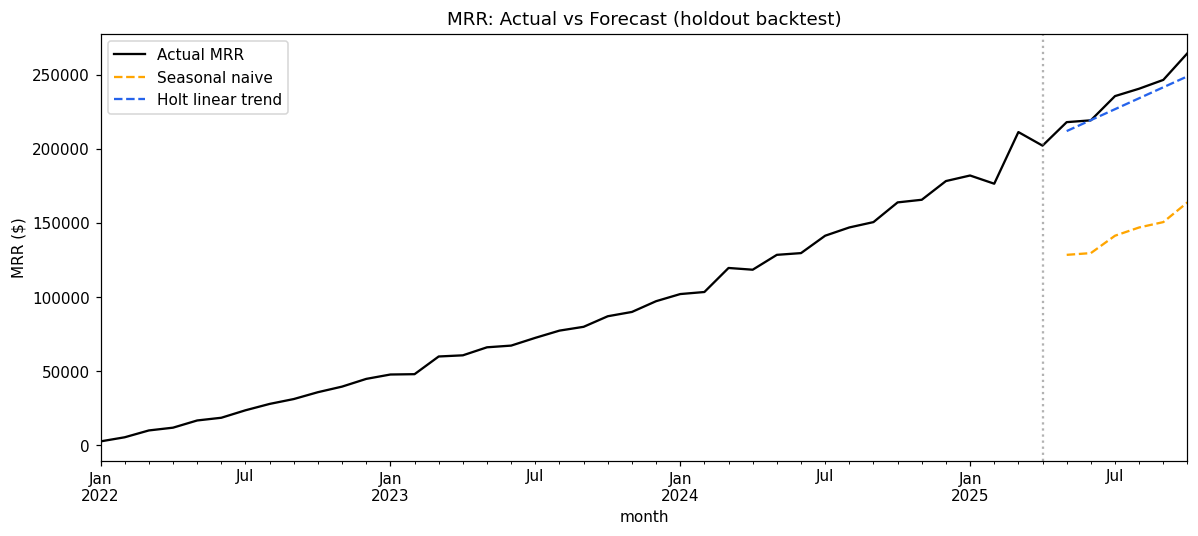

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
series.plot(ax=ax, label="Actual MRR", color="black")
pd.Series(naive_fc, index=test.index).plot(ax=ax, label="Seasonal naive", linestyle="--", color="orange")
pd.Series(holt_fc, index=test.index).plot(ax=ax, label="Holt linear trend", linestyle="--", color="#2563eb")
ax.axvline(train.index[-1], color="gray", linestyle=":", alpha=0.6)
ax.set_title("MRR: Actual vs Forecast (holdout backtest)")
ax.set_ylabel("MRR ($)")
ax.legend()
plt.tight_layout()
plt.show()

## Final 6-month forward forecast (using all available history, best model)

Best model on backtest: Holt linear trend

       month  forecast_mrr
0 2025-11-01      268233.0
1 2025-12-01      277065.0
2 2026-01-01      285896.0
3 2026-02-01      294728.0
4 2026-03-01      303560.0
5 2026-04-01      312392.0


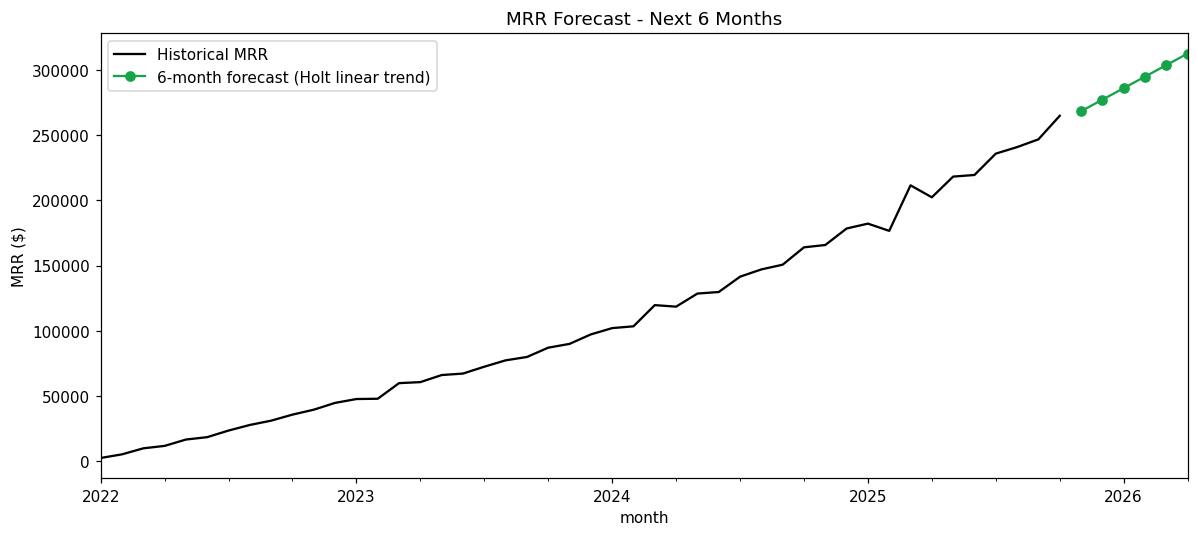

In [7]:
best_model_name = results.loc[results["MAPE (%)"].idxmin(), "model"]
full_series = series
future_idx = pd.date_range(full_series.index[-1] + pd.DateOffset(months=1), periods=6, freq="MS")

if best_model_name == "Holt linear trend":
    future_fc = holt_linear(full_series, 6)
else:
    future_fc = seasonal_naive_forecast(full_series, 6)

forecast_df = pd.DataFrame({"month": future_idx, "forecast_mrr": future_fc})
print(f"Best model on backtest: {best_model_name}\n")
print(forecast_df.round(0))

fig, ax = plt.subplots(figsize=(11, 5))
full_series.plot(ax=ax, label="Historical MRR", color="black")
pd.Series(future_fc, index=future_idx).plot(ax=ax, label=f"6-month forecast ({best_model_name})", color="#16a34a", marker="o")
ax.set_title("MRR Forecast - Next 6 Months")
ax.set_ylabel("MRR ($)")
ax.legend()
plt.tight_layout()
plt.show()

## Limitations and planning takeaway

- Holt's linear trend outperforms the seasonal-naive baseline on this
  backtest, but with under 4 years of history the model has limited ability
  to distinguish true seasonality from noise -- treat month-level swings
  in the forecast cautiously and prioritize the trend direction over exact
  values.
- Neither model incorporates planned product changes (e.g. the guided
  onboarding rollout from notebook 04), which should push activation --
  and therefore paid conversion and MRR -- above this baseline forecast.
- **Planning takeaway:** MRR is on a [see chart] trajectory over the next
  two quarters under current conditions; budget and hiring plans should
  use the Holt forecast as the base case and treat the experiment-driven
  upside as a stretch scenario, not the plan of record.